<b><h1>Task 1 – Data Preparation
# 1. Import libraries

In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [14]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2478s 15us/step


# 2. EXPLORE DATASET

In [15]:
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


# 3.CLASS LABELS

In [16]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Number of classes:", len(class_names))
print("Classes:", class_names)


Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# 4. NORMALIZE PIXEL VALUES

In [17]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


# 5. VISUALIZE SAMPLE IMAGES

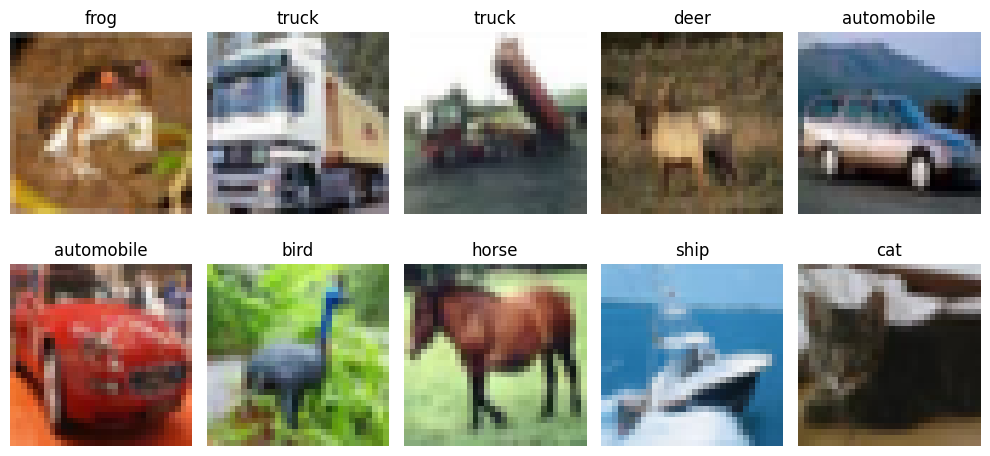

In [18]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()


# 6. CHECK CLASS DISTRIBUTION

In [19]:
labels, counts = np.unique(y_train, return_counts=True)
print("\nClass Distribution:")
for label, count in zip(labels, counts):
    print(class_names[label], ":", count)



Class Distribution:
airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


<b><h1>
Task 2 – CNN Model Development


In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dropout, Flatten, Dense

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Build CNN Model

In [21]:
model = Sequential([
    # Convolution Layer
    Conv2D(32, (3, 3), activation="relu",input_shape=(32, 32, 3)),
    # Max Pooling Layer
    MaxPooling2D((2, 2)),
    # Convolution Layer
    Conv2D(64, (3, 3), activation="relu"),
    # Max Pooling Layer
    MaxPooling2D((2, 2)),
    # Dropout
    Dropout(0.25),
    # Flatten
    Flatten(),
    # Dense Layer
    Dense(128, activation="relu"),
    # Dropout
    Dropout(0.5),
    # Softmax Output Layer
    Dense(10, activation="softmax")])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 2. Model Summary

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Compile Model

In [23]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

# 4. Train Model

In [24]:
history = model.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.3788 - loss: 1.6952 - val_accuracy: 0.5220 - val_loss: 1.3608
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.5017 - loss: 1.3877 - val_accuracy: 0.5662 - val_loss: 1.2348
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.5498 - loss: 1.2736 - val_accuracy: 0.6159 - val_loss: 1.1228
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.5842 - loss: 1.1853 - val_accuracy: 0.6385 - val_loss: 1.0497
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.6053 - loss: 1.1242 - val_accuracy: 0.6440 - val_loss: 1.0328
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.6186 - loss: 1.0840 - val_accuracy: 0.6679 - val_loss: 0.9572
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.6325 - loss: 1.0420 - val_accuracy: 0.6731 - val_loss: 0.9469
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.6460 - loss: 1.0083 - 

# 5. Evaluate Model

In [25]:
test_loss, test_accuracy = model.evaluate( X_test,y_test,verbose=0)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


Test Accuracy: 0.6966999769210815
Test Loss: 0.8915311694145203


# 6. Accuracy Graph

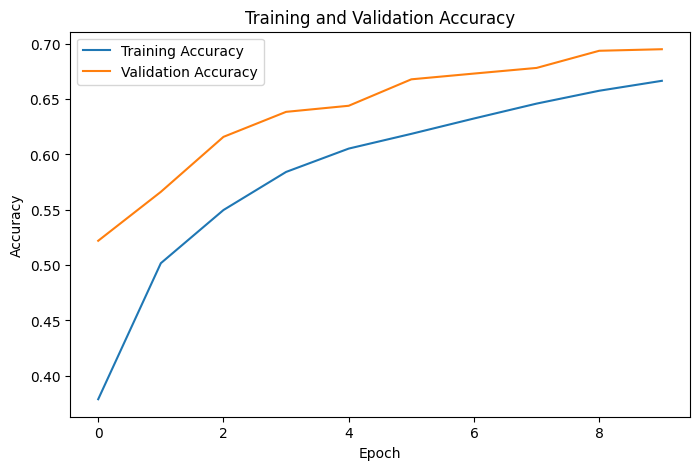

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


# 7. Loss Graph

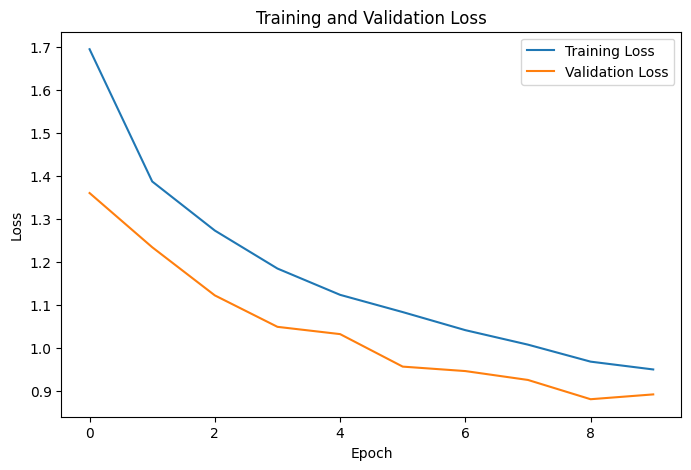

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# 8. Make Predictions

In [28]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


# 9. Confusion Matrix


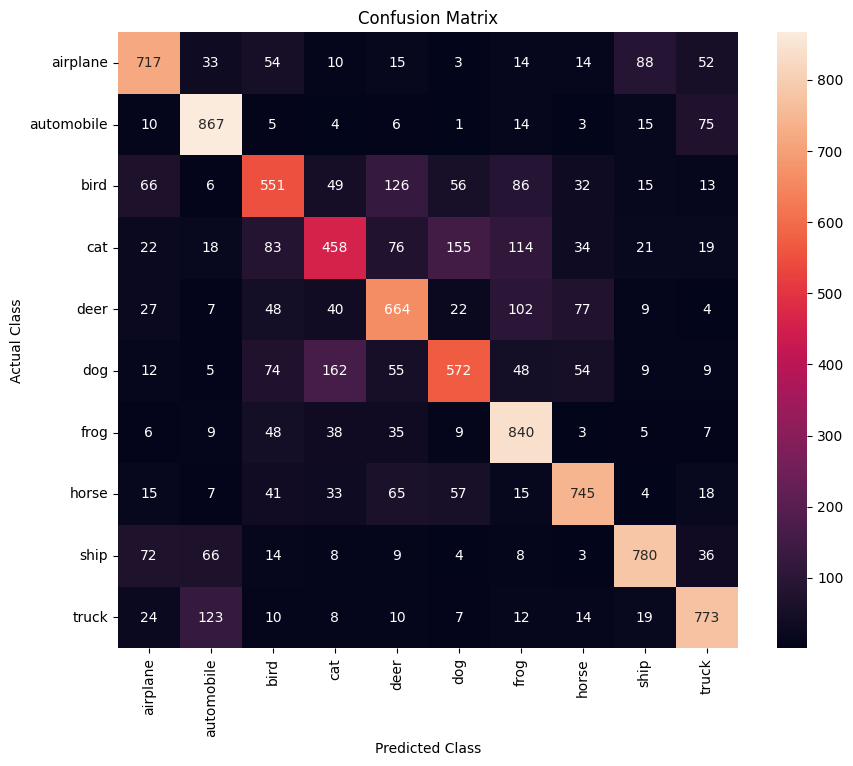

In [29]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

# 10. Classification Report

In [30]:
print("Classification Report")
print(classification_report(y_test,y_pred_classes,target_names=class_names))

Classification Report
              precision    recall  f1-score   support

    airplane       0.74      0.72      0.73      1000
  automobile       0.76      0.87      0.81      1000
        bird       0.59      0.55      0.57      1000
         cat       0.57      0.46      0.51      1000
        deer       0.63      0.66      0.64      1000
         dog       0.65      0.57      0.61      1000
        frog       0.67      0.84      0.75      1000
       horse       0.76      0.74      0.75      1000
        ship       0.81      0.78      0.79      1000
       truck       0.77      0.77      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.69      0.70      0.69     10000
weighted avg       0.69      0.70      0.69     10000



#11. Predictions


In [32]:
index = 11
image = X_test[index]
prediction = model.predict(np.expand_dims(image, axis=0))
predicted_class = np.argmax(prediction)
print("Actual Class:",
      class_names[y_test[index][0]])
print("Predicted Class:",
      class_names[predicted_class])
print("Confidence:",
      np.max(prediction) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Actual Class: truck
Predicted Class: truck
Confidence: 96.06775


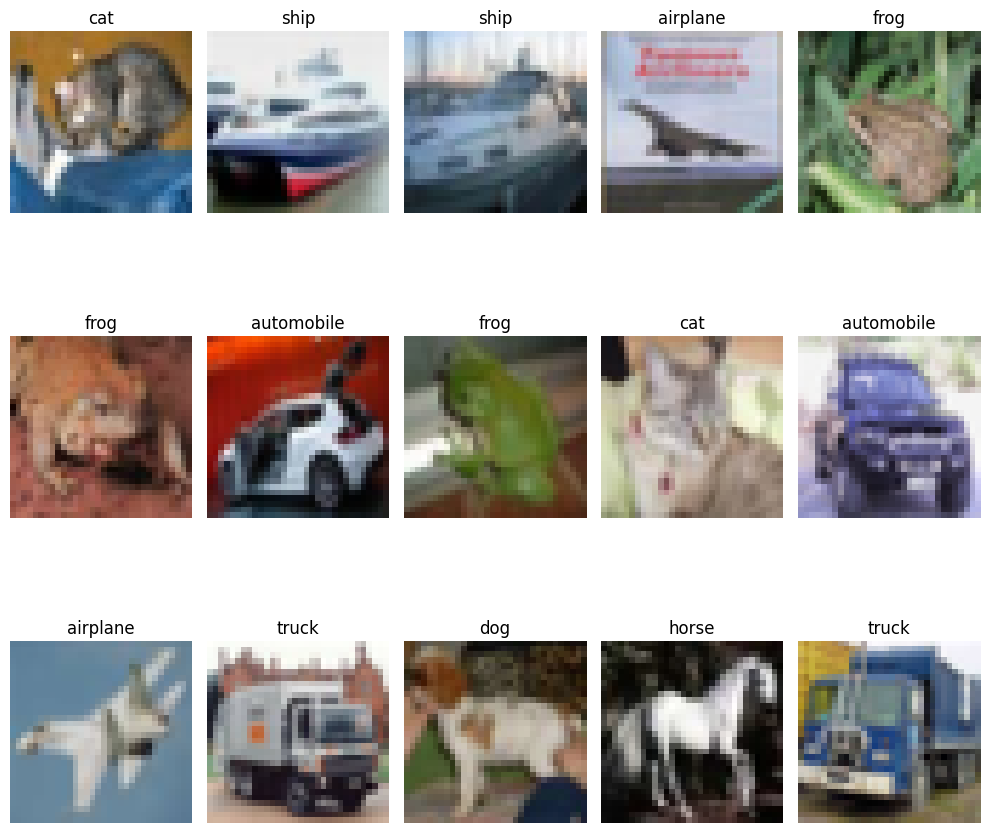

In [33]:
plt.figure(figsize=(10, 10))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i])
    plt.title(class_names[y_test[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()


<h1><b>Task 3 – Transfer Learning using MobileNetV2

In [34]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Resize CIFAR-10 Images

In [35]:
X_train= tf.image.resize(X_train, (96, 96))
X_test = tf.image.resize(X_test, (96, 96))
print("New training shape:", X_train.shape)
print("New testing shape:", X_test.shape)

New training shape: (50000, 96, 96, 3)
New testing shape: (10000, 96, 96, 3)


# 2. Load Pretrained MobileNetV2

In [36]:
base_model = MobileNetV2(weights="imagenet",include_top=False,input_shape=(96, 96, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# 3. Freeze Base Model

In [37]:
base_model.trainable = False


# 4. Add Custom Classifier

In [38]:
model_transfer = Sequential([base_model,GlobalAveragePooling2D(),Dense(128,activation="relu"),Dropout(0.5),Dense(10,activation="softmax")])

# 5. Model Summary

In [39]:
model_transfer.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 6. Compile Model

In [40]:
model_transfer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 7. Train Model

In [41]:
history_transfer = model_transfer.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 278s 439ms/step - accuracy: 0.6602 - loss: 0.9963 - val_accuracy: 0.7628 - val_loss: 0.6813
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 362ms/step - accuracy: 0.7414 - loss: 0.7547 - val_accuracy: 0.7861 - val_loss: 0.6168
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 355ms/step - accuracy: 0.7611 - loss: 0.6998 - val_accuracy: 0.7903 - val_loss: 0.6009
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 335ms/step - accuracy: 0.7716 - loss: 0.6659 - val_accuracy: 0.7967 - val_loss: 0.5852
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 312s 415ms/step - accuracy: 0.7801 - loss: 0.6399 - val_accuracy: 0.7958 - val_loss: 0.5918
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 344ms/step - accuracy: 0.7860 - loss: 0.6176 - val_accuracy: 0.8025 - val_loss: 0.5731
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 333ms/step - accuracy: 0.7905 - loss: 0.5979 - val_accuracy: 0.8042 - val_loss: 0.5687
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 332ms/step - accuracy: 0.7991 -

# 8. Evaluate Model

In [42]:
test_loss, test_accuracy = model_transfer.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Transfer Learning Accuracy:", test_accuracy)
print("Transfer Learning Loss:", test_loss)

Transfer Learning Accuracy: 0.8091999888420105
Transfer Learning Loss: 0.56415855884552



# 9. Accuracy Graph

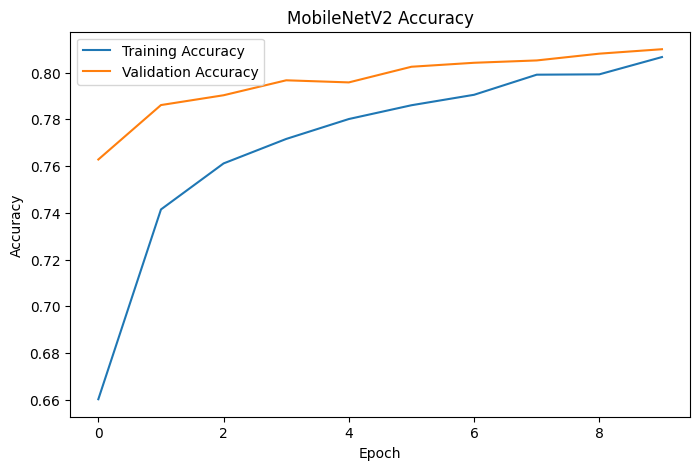

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history["accuracy"],label="Training Accuracy")
plt.plot(history_transfer.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.show()


# 10. Loss Graph

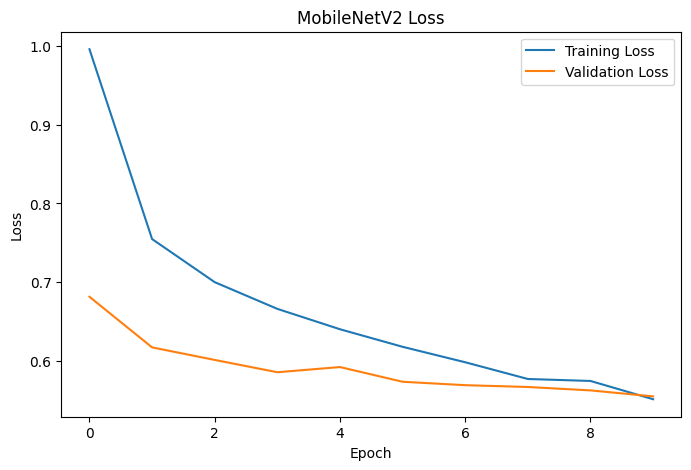

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history["loss"],label="Training Loss")
plt.plot(history_transfer.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()
plt.show()


# 11. Predictions

In [45]:
y_pred_transfer = model_transfer.predict(X_test)
y_pred_transfer_classes = np.argmax(y_pred_transfer, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 128ms/step


# 12. Confusion Matrix

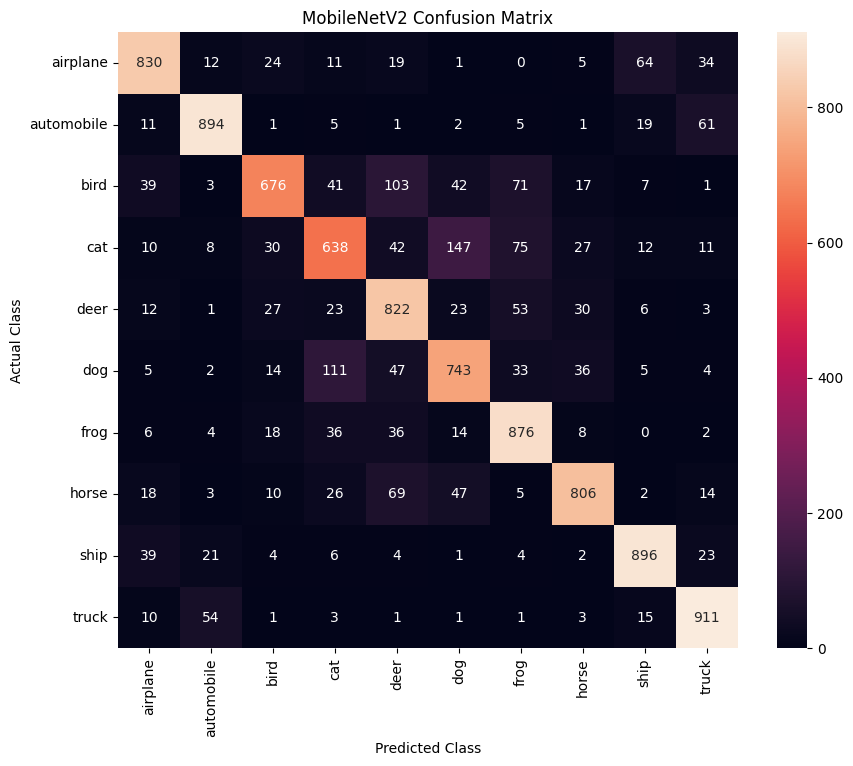

In [46]:
cm_transfer = confusion_matrix(y_test,y_pred_transfer_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_transfer,annot=True,fmt="d",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

# 13. Classification Report

In [47]:
print("MobileNetV2 Classification Report")
print(classification_report(y_test,y_pred_transfer_classes,target_names=class_names))

MobileNetV2 Classification Report
              precision    recall  f1-score   support

    airplane       0.85      0.83      0.84      1000
  automobile       0.89      0.89      0.89      1000
        bird       0.84      0.68      0.75      1000
         cat       0.71      0.64      0.67      1000
        deer       0.72      0.82      0.77      1000
         dog       0.73      0.74      0.74      1000
        frog       0.78      0.88      0.83      1000
       horse       0.86      0.81      0.83      1000
        ship       0.87      0.90      0.88      1000
       truck       0.86      0.91      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



#14.Predictions

In [52]:
index = 11
image = X_test[index]
prediction = model_transfer.predict(np.expand_dims(image, axis=0))
predicted_class = np.argmax(prediction)
print("Actual Class:",
      class_names[y_test[index][0]])
print("Predicted Class:",
      class_names[predicted_class])
print("Confidence:",
      np.max(prediction) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Actual Class: truck
Predicted Class: truck
Confidence: 99.871155


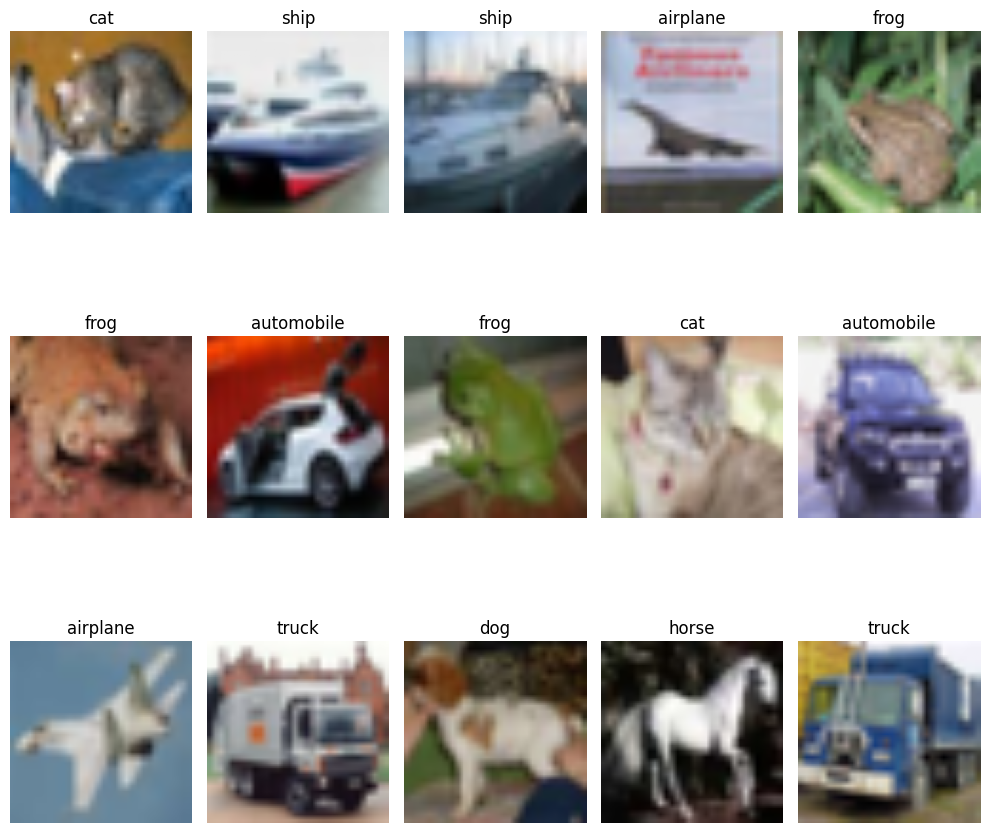

In [53]:
plt.figure(figsize=(10, 10))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i])
    plt.title(class_names[y_test[i][0]])
    plt.axis("off")
plt.tight_layout()

#Task - 5 Model Analysis -Comparison